In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from speechbrain.pretrained import EncoderClassifier
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
import torchaudio
import speechbrain as sb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from speechbrain.inference import SpeakerRecognition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram, GriffinLim
import os
import torchaudio
import torch
from sklearn.model_selection import train_test_split
from speechbrain.pretrained import EncoderClassifier
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as transforms

/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/2d/mf93wtk914vbrkclc8d3hrt40000gn/T/ipykernel_96379/1754867656.py:4: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderClassifier


In [2]:
# Check GPU availability and set device accordingly
device = torch.device("mps")
print("Device:",device)

Device: mps


In [3]:
num_classes = 50

# # Load the pre-trained ECAPA TDNN model
# pretrained_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
# pretrained_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)  # Adjusting output layer

# Load the fine-tuned model
fine_tuned_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
fine_tuned_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)
fine_tuned_classifier.load_state_dict(torch.load("fine_tuned_ecapa_tdnn_200.pth"))

dataset_path = 'DigitUtter-IITDH-dataset-master'

/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/speechbrain/utils/autocast.py:68: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/speechbrain/utils/checkpoints.py:194: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless 

In [4]:
print(fine_tuned_classifier)

EncoderClassifier(
  (mods): ModuleDict(
    (compute_features): Fbank(
      (compute_STFT): STFT()
      (compute_fbanks): Filterbank()
      (compute_deltas): Deltas()
      (context_window): ContextWindow()
    )
    (mean_var_norm): InputNormalization()
    (embedding_model): ECAPA_TDNN(
      (blocks): ModuleList(
        (0): TDNNBlock(
          (conv): Conv1d(
            (conv): Conv1d(80, 1024, kernel_size=(5,), stride=(1,))
          )
          (activation): ReLU()
          (norm): BatchNorm1d(
            (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): SERes2NetBlock(
          (tdnn1): TDNNBlock(
            (conv): Conv1d(
              (conv): Conv1d(1024, 1024, kernel_size=(1,), stride=(1,))
            )
            (activation): ReLU()
            (norm): BatchNorm1d(
              (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
     

In [5]:
# Custom dataset class
class DigitUtterDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.audio_paths = []
        self.labels = []
        self._prepare_data()

    def _prepare_data(self):
        # Assuming directory structure is `data_dir/speaker_id/session_x/audio.wav`
        speakers = sorted(os.listdir(self.data_dir))  # Sort speakers to assign consistent indices
        print(speakers)
        speakers.remove('.DS_Store')
        # Step 2: Create a mapping from speaker names to integer indices
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}
        # Optional: If you need just the indices in a set
        speakers_mod = set(speaker_to_index.values())
        #print(speakers_mod)
        
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}  # Map to indices
    
        for speaker in speakers:
            speaker_path = os.path.join(dataset_path, speaker)
            #print("Speaker Path",speaker_path)
            if os.path.isdir(speaker_path):
                for session in ['A', 'B']:  # Iterate over sessions
                    session_path = os.path.join(speaker_path, f"{speaker}{session}")
                    #print("Session Path", session_path)
                    if os.path.isdir(session_path):
                        #print(session_path)
                        for audio_file in os.listdir(session_path):
                            #print("Audio File Path ", audio_file)
                            # Check if the file is a .wav file
                            if audio_file.endswith('.wav'):
                                audio_path = os.path.join(session_path, audio_file)
                                self.audio_paths.append(audio_path)
                                #print(speaker_to_index[speaker])
                                self.labels.append(speaker_to_index[speaker])  # Use speaker ID as label 
                            else:
                                print("Not wave file")
                            # Check for duplicates
                                # if audio_path not in unique_samples:
                                #     unique_samples.add(audio_path)
                                #     self.audio_paths.append(audio_path)
                                #     self.labels.append(speaker)
                                # else:
                                #     print(f"Duplicate found: {audio_path}")
                    else:
                        print("This is not directory ->", session_path)   
    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = int(self.labels[idx])
        #print(f"Loading sample {idx}: {audio_path}, label: {label}")  # Debug statement

        audio, sample_rate = torchaudio.load(audio_path)  # Load audio file
        if self.transform:
            audio = self.transform(audio)
        return audio.squeeze(0), label  # Remove unnecessary channel dimension

    
# Custom collate function for padding
def collate_fn(batch):
    # Separate the batch into audio tensors and labels
    audios, labels = zip(*batch)

   # Calculate original lengths before padding
    lengths = torch.tensor([audio.shape[0] for audio in audios])

    # Pad all audio tensors to the length of the longest audio in the batch
    padded_audios = pad_sequence(audios, batch_first=True)  # Pads to [batch_size, max_len]

    labels = torch.tensor([int(label) for label in labels])

    return padded_audios, labels, lengths


In [6]:
# Prepare the dataset
dataset = DigitUtterDataset(dataset_path)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']
Not wave file


In [7]:

def get_logits_and_labels(model, data_loader):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            audio, labels, lengths = batch
            embeddings = model.encode_batch(audio)
            logits = model.mods.classifier(embeddings)
            logits = logits.squeeze(1)  # Remove extra dimension
            
            all_logits.append(logits)
            all_labels.append(labels)

    return torch.cat(all_logits), torch.cat(all_labels)

# Get logits for both models
#pretrained_logits, pretrained_labels = get_logits_and_labels(pretrained_classifier, test_loader)
fine_tuned_logits, fine_tuned_labels = get_logits_and_labels(fine_tuned_classifier, test_loader)

In [8]:
def distillation_loss(student_logits, teacher_logits, true_labels, T, alpha):
 # Ensure logits are extracted if returned as a tuple
    if isinstance(teacher_logits, tuple):
        teacher_logits = teacher_logits[0]
        print("Updated techers logits")
    if isinstance(student_logits, tuple):
        student_logits = student_logits[0]
        print("Updated student logits")
    
    # Cross-entropy loss between student and true labels
    ce_loss = nn.CrossEntropyLoss()(student_logits, true_labels)
    
    # Softened teacher and student outputs
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    student_soft = F.log_softmax(student_logits / T, dim=1)

    # print(teacher_logits.shape)
    # print(student_logits.shape)
    
    # Kullback-Leibler divergence loss for distillation
    kl_loss = F.kl_div(student_soft, teacher_soft, reduction='batchmean')
    
    # Total loss is a weighted sum of the two losses
    return alpha * ce_loss + (1 - alpha) * kl_loss



import math
import torch
import torch.nn as nn
import random

class AAMSoftmax(nn.Module):
    def __init__(self, in_features, out_features, margin=0.2, scale=30):
        super(AAMSoftmax, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        cosine = nn.functional.linear(nn.functional.normalize(x), nn.functional.normalize(self.weight))
        if labels is None:
            return cosine * self.scale
        phi = cosine - self.margin
        one_hot = torch.zeros(cosine.size(), device=x.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.scale
        return output

class SEModule(nn.Module):
    def __init__(self, channels, reduction=4):
        super(SEModule, self).__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, channels // reduction, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(channels // reduction, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(x)

class Bottle2neck(nn.Module):
    def __init__(self, inplanes, planes, kernel_size, dilation, scale):
        super(Bottle2neck, self).__init__()

        width = int(math.floor(planes / scale))
        self.conv1 = nn.Conv1d(inplanes, width * scale, kernel_size=1)
        self.bn1 = nn.BatchNorm1d(width * scale)
        self.nums = scale - 1

        self.convs = nn.ModuleList([
            nn.Conv1d(width, width, kernel_size=kernel_size, dilation=dilation, padding=math.floor(kernel_size / 2) * dilation)
            for _ in range(self.nums)
        ])
        self.bns = nn.ModuleList([nn.BatchNorm1d(width) for _ in range(self.nums)])

        self.conv3 = nn.Conv1d(width * scale, planes, kernel_size=1)
        self.bn3 = nn.BatchNorm1d(planes)
        self.relu = nn.ReLU()
        self.se = SEModule(planes)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.relu(x)
        x = self.bn1(x)

        # Change splits to a list
        splits = list(torch.split(x, x.size(1) // (len(self.convs) + 1), dim=1))
        
        for i, conv in enumerate(self.convs):
            splits[i + 1] = torch.relu(self.bns[i](conv(splits[i + 1])))
        
        out = torch.cat(splits, dim=1)
        out = self.bn3(self.conv3(out))
        
        out = self.se(out)
        out += identity
        return out


class W2V2_ECAPA_Student(nn.Module):
    def __init__(self, embedding_size=128, num_classes=10, C=128, aam_margin=0.2, aam_scale=30):
        super(W2V2_ECAPA_Student, self).__init__()

        self.norm = nn.InstanceNorm1d(128)
        #self.conv1 = nn.Conv1d(128, C, kernel_size=5, padding=2)
        self.conv1 = nn.Conv1d(1, C, kernel_size=5, padding=2)

        self.bn1 = nn.BatchNorm1d(C)
        
        self.layer1 = Bottle2neck(C, C, kernel_size=3, dilation=2, scale=8)
        self.layer2 = Bottle2neck(C, C, kernel_size=3, dilation=3, scale=8)
        self.layer3 = Bottle2neck(C, C, kernel_size=3, dilation=4, scale=8)
        
        self.layer4 = nn.Conv1d(C * 3, 512, kernel_size=1)
        self.attention = nn.Sequential(
            nn.Conv1d(1536, 128, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Tanh(),
            nn.Conv1d(128, 512, kernel_size=1),
            nn.Softmax(dim=2)
        )
        
        self.bn5 = nn.BatchNorm1d(1024)
        self.fc6 = nn.Linear(1024, embedding_size)
        self.bn6 = nn.BatchNorm1d(embedding_size)
        self.softmax_loss = AAMSoftmax(embedding_size, num_classes, margin=aam_margin, scale=aam_scale)

    def forward(self, x, labels=None):
        x = self.norm(x)
        x = torch.relu(self.bn1(self.conv1(x)))

        x1 = self.layer1(x)
        x2 = self.layer2(x + x1)
        x3 = self.layer3(x + x1 + x2)

        x = torch.cat((x1, x2, x3), dim=1)
        x = torch.relu(self.layer4(x))
        
        mu = torch.mean(x, dim=2)
        sg = torch.sqrt(torch.var(x, dim=2).clamp(min=1e-4))
        x = torch.cat((mu, sg), dim=1)

        x = torch.relu(self.bn5(x))
        x = self.fc6(x)
        x = self.bn6(x)

        if labels is not None:
            return self.softmax_loss(x, labels)
        return x

# Example instantiation
args = {
    'embedding_size': 50,
    'n_class': 50,  # Adjust for the number of classes in the DigitUtter dataset
    'C': 128,
    'aam_margin': 0.2,
    'aam_scale': 30
}
student_model = W2V2_ECAPA_Student(
    embedding_size=args['embedding_size'], 
    num_classes=args['n_class'], 
    C=args['C'], 
    aam_margin=args['aam_margin'], 
    aam_scale=args['aam_scale']
)


In [9]:
T = 3  # Temperature
alpha = 0.8  # Weighting factor between CE loss and distillation loss
learning_rate = 0.001
num_epochs = 100

# Step 5: Define optimizer
optimizer = optim.Adam(student_model.parameters(), lr=learning_rate)

train_losses = []
for epoch in range(num_epochs):
    student_model.train()
    running_loss = 0.0

    for inputs, labels, _ in train_loader:

        # Forward pass for teacher model (get features from the encoder)
        with torch.no_grad():
            teacher_logits = fine_tuned_classifier.mods.classifier(fine_tuned_classifier.encode_batch(inputs))

        # Extract features from the fine-tuned model
        student_inputs = fine_tuned_classifier.encode_batch(inputs)

        # Forward pass for student model with the extracted features
        student_logits = student_model(student_inputs)
        # Assuming student_logits has shape (16, 1, 50)
        student_logits = student_logits.squeeze(1)  # Now student_logits will have shape (16, 50)

        # Compute distillation loss
        loss = distillation_loss(student_logits, teacher_logits, labels, T, alpha)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

torch.save(student_model.state_dict(), "student_model_tt.pth")

/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/torch/nn/modules/instancenorm.py:88: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  warnings.warn(f"input's size at dim={feature_dim} does not match num_features. "


Epoch 1/100, Loss: 628.3982556152343
Epoch 2/100, Loss: 627.4935913085938
Epoch 3/100, Loss: 627.4777355957032
Epoch 4/100, Loss: 627.470361328125
Epoch 5/100, Loss: 627.45947265625
Epoch 6/100, Loss: 627.4556396484375
Epoch 7/100, Loss: 627.4491479492187
Epoch 8/100, Loss: 627.4376159667969
Epoch 9/100, Loss: 627.4264514160157
Epoch 10/100, Loss: 627.4186022949219
Epoch 11/100, Loss: 627.4078784179687
Epoch 12/100, Loss: 627.3932067871094
Epoch 13/100, Loss: 627.3881689453125
Epoch 14/100, Loss: 627.376787109375
Epoch 15/100, Loss: 627.3626110839843
Epoch 16/100, Loss: 627.3441796875
Epoch 17/100, Loss: 627.3340881347656
Epoch 18/100, Loss: 627.3265295410156
Epoch 19/100, Loss: 627.3092138671875
Epoch 20/100, Loss: 627.3022216796875
Epoch 21/100, Loss: 627.2981408691406
Epoch 22/100, Loss: 627.284326171875
Epoch 23/100, Loss: 627.2724401855469
Epoch 24/100, Loss: 627.255078125
Epoch 25/100, Loss: 627.2593981933594
Epoch 26/100, Loss: 627.2410522460938
Epoch 27/100, Loss: 627.229489746

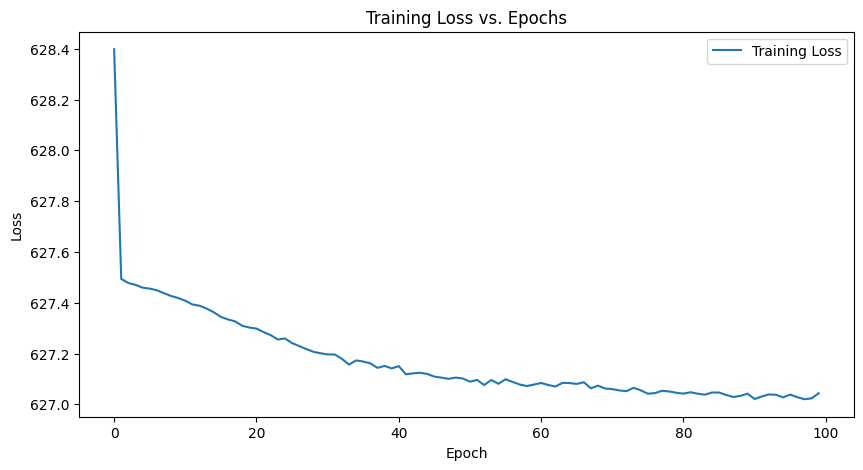

In [10]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epochs')
plt.legend()
plt.show()

In [11]:
print(student_model)

W2V2_ECAPA_Student(
  (norm): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (conv1): Conv1d(1, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Bottle2neck(
    (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (convs): ModuleList(
      (0-6): 7 x Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    )
    (bns): ModuleList(
      (0-6): 7 x BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv3): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (se): SEModule(
      (se): Sequential(
        (0): AdaptiveAvgPool1d(output_size=1)
        (1): Conv1d(128, 32, kerne

In [12]:

# Custom dataset class
class DigitUtterDataset(Dataset):
    
    def __init__(self, data_dir, type, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.audio_paths = []
        self.labels = []
        if type == "enroll":
            self.folder = "C"
        if type == "verify":
            self.folder = "D"
        self._prepare_data()


    def _prepare_data(self):
        # Assuming directory structure is `data_dir/speaker_id/session_x/audio.wav`
        speakers = sorted(os.listdir(self.data_dir))  # Sort speakers to assign consistent indices
        print(speakers)
        speakers.remove('.DS_Store')
        # Step 2: Create a mapping from speaker names to integer indices
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}
        # Optional: If you need just the indices in a set
        speakers_mod = set(speaker_to_index.values())
        #print(speakers_mod)
        
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}  # Map to indices
    
        for speaker in speakers:
            speaker_path = os.path.join(dataset_path, speaker)
            #print("Speaker Path",speaker_path)
            if os.path.isdir(speaker_path):
                for session in [self.folder]:  # Iterate over sessions
                    session_path = os.path.join(speaker_path, f"{speaker}{session}")
                    #print("Session Path", session_path)
                    if os.path.isdir(session_path):
                        #print(session_path)
                        for audio_file in os.listdir(session_path):
                            #print("Audio File Path ", audio_file)
                            # Check if the file is a .wav file
                            if audio_file.endswith('.wav'):
                                audio_path = os.path.join(session_path, audio_file)
                                self.audio_paths.append(audio_path)
                                #print(speaker_to_index[speaker])
                                self.labels.append(speaker_to_index[speaker])  # Use speaker ID as label 
                            else:
                                print("Not wave file")
                            # Check for duplicates
                                # if audio_path not in unique_samples:
                                #     unique_samples.add(audio_path)
                                #     self.audio_paths.append(audio_path)
                                #     self.labels.append(speaker)
                                # else:
                                #     print(f"Duplicate found: {audio_path}")
                    else:
                        print("This is not directory ->", session_path)   
    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = int(self.labels[idx])
        #print(f"Loading sample {idx}: {audio_path}, label: {label}")  # Debug statement

        audio, sample_rate = torchaudio.load(audio_path)  # Load audio file
        if self.transform:
            audio = self.transform(audio)
        return audio.squeeze(0), label  # Remove unnecessary channel dimension

    
# Custom collate function for padding
def collate_fn(batch):
    # Separate the batch into audio tensors and labels
    audios, labels = zip(*batch)

   # Calculate original lengths before padding
    lengths = torch.tensor([audio.shape[0] for audio in audios])

    # Pad all audio tensors to the length of the longest audio in the batch
    padded_audios = pad_sequence(audios, batch_first=True)  # Pads to [batch_size, max_len]

    labels = torch.tensor([int(label) for label in labels])

    return padded_audios, labels, lengths


# Generate enrollment embeddings
def generate_enrollment_embeddings(model, enrollment_loader):
    enrollment_embeddings = {}
    with torch.no_grad():
        for inputs, labels, _ in enrollment_loader:
            student_inputs = fine_tuned_classifier.encode_batch(inputs)
            embeddings = model(student_inputs)
            for i, label in enumerate(labels):
                speaker_id = label.item()
                if speaker_id not in enrollment_embeddings:
                    enrollment_embeddings[speaker_id] = []
                enrollment_embeddings[speaker_id].append(embeddings[i].numpy())

    # Average embeddings for each speaker
    for speaker_id in enrollment_embeddings:
        enrollment_embeddings[speaker_id] = np.mean(enrollment_embeddings[speaker_id], axis=0)

    return enrollment_embeddings

In [13]:
dataset_path = 'DigitUtter-IITDH-dataset-master' 
enroll_dataset = DigitUtterDataset(dataset_path, type="enroll")
enrollment_loader = DataLoader(enroll_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
enrollment_embeddings = generate_enrollment_embeddings(student_model, enrollment_loader)
print("Enrollment embeddings completed, " + str(len(enrollment_embeddings)))

['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']
Enrollment embeddings completed, 50


In [14]:
from sklearn.metrics import roc_curve
import numpy as np
import torch
import torch.nn.functional as F

# Assuming `model`, `verification_loader`, and `enrollment_embeddings` are defined and ready

def generate_verification_scores(model, verification_loader, enrollment_embeddings):
    scores = []
    labels = []
    with torch.no_grad():
        for inputs, labels_batch, _ in verification_loader:
            student_inputs = fine_tuned_classifier.encode_batch(inputs)
            verification_embeddings = student_model(student_inputs)
            for i, label in enumerate(labels_batch):
                speaker_id = label.item()
                # print("Comapring =====>")
                # print(torch.tensor(enrollment_embeddings[speaker_id]))
                # print("WITH  =====>")
                #print(verification_embeddings[i])
                # Positive pair (same speaker)
                if speaker_id in enrollment_embeddings:
                    score = F.cosine_similarity(
                        torch.tensor(enrollment_embeddings[speaker_id]).squeeze(),
                        verification_embeddings[i].squeeze(),
                        dim=0
                    )
                    #print("SCORE", score)
                    scores.append(score)
                    labels.append(1)  # Positive (same speaker)

                # Negative pair (different speaker)
                other_speaker_id = np.random.choice([id for id in enrollment_embeddings.keys() if id != speaker_id])
                score = F.cosine_similarity(
                    torch.tensor(enrollment_embeddings[other_speaker_id]).squeeze(),
                    verification_embeddings[i].squeeze(),
                    dim=0
                )
                scores.append(score)
                labels.append(0)  # Negative (different speaker)
    
    return scores, labels

In [15]:
# Generate enrollment and verification embeddings
verify_dataset = DigitUtterDataset(dataset_path, type="verify")
verify_loader = DataLoader(verify_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
scores_fine_tuned, labels_finetuned = generate_verification_scores(student_model, verify_loader, enrollment_embeddings)


['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


In [16]:
# Calculate EER
def calculate_eer(scores, labels):
    scores = np.array(scores)
    labels = np.array(labels)

    if len(set(labels)) < 2:
        raise ValueError("Labels must contain at least two classes for EER calculation.")
        
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    
    return eer, eer_threshold

In [17]:

eer, eer_threshold = calculate_eer(scores_fine_tuned, labels_finetuned)
print(f"Knowledge Distilled EER: {eer * 100:.2f}% at threshold: {eer_threshold:.4f}")

Knowledge Distilled EER: 49.10% at threshold: 0.0532


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_eer(scores, labels, str=None):
    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr  # False Negative Rate (FNR) is 1 - TPR

    # Find the Equal Error Rate (EER)
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    # Plot FAR, FRR, and the EER point
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, fpr, label="False Acceptance Rate (FAR)", color="blue")
    plt.plot(thresholds, fnr, label="False Rejection Rate (FRR)", color="red")
    plt.axvline(eer_threshold, color="green", linestyle="--", label=f"EER Threshold: {eer_threshold:.2f}")
    plt.scatter(eer_threshold, eer, color="purple", s=100, zorder=5, label=f"EER: {eer * 100:.2f}%")
    plt.xlabel("Threshold")
    plt.ylabel("Error Rate")
    plt.title("Equal Error Rate (EER) Curve for " + str)
    plt.legend()
    plt.grid(True)
    plt.show()


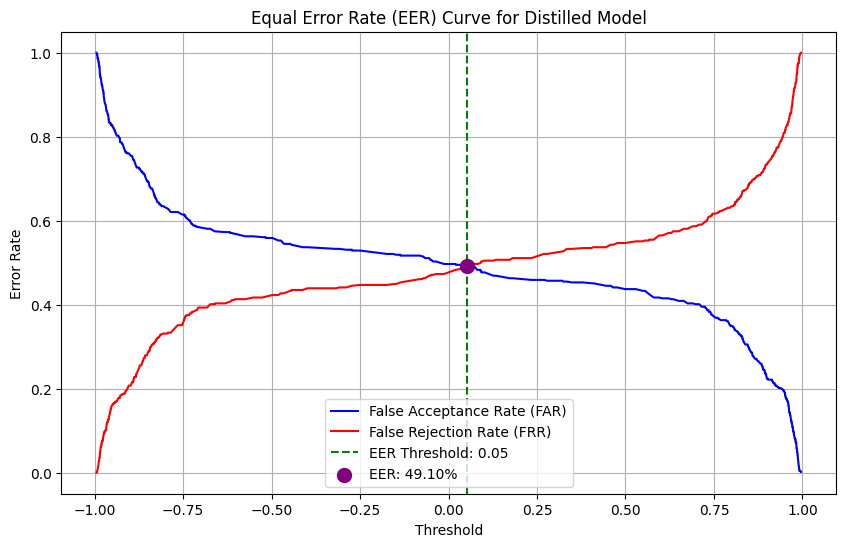

In [19]:
# Call the plot function with the generated scores and labels
plot_eer(scores_fine_tuned, labels_finetuned, str = "Distilled Model")